In [1]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [2]:
barred_target = pd.read_csv('../data/matched_barred_ps1_resolved.csv')
unbarred_target = pd.read_csv('../data/matched_unbarred_ps1_resolved.csv')

In [3]:
target = pd.read_csv('../all_sample_20260702.csv')
target = pd.merge(target, barred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target = pd.merge(target, unbarred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target['class'] = target['class_x'].combine_first(target['class_y'])
target = target.drop(['class_x', 'class_y'], axis=1)

target = target[target['class'].isin(['barred', 'unbarred'])]
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

In [ ]:
import numpy as np
import pandas as pd
import glob
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18
# 匯入您自訂的誤差估算函數
from mc_density_error import calculate_single_target_fof_error

def compute_index_for_target(i):
    # 1. 讀取與篩選匹配文件
    file_list = glob.glob(f'../data/catalog/ps1/matched/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
    if len(file_list) == 0:
        return [-999]*3

    target_z = float(target.paliya_Z.iloc[i])
    df = pd.read_csv(file_list[0])
    df = df[df.Absolute_Mag_r < 20.5]

    if len(df) == 0:
        return [-999]*3

    # 2. 提取周圍星系數據
    surround_z = df['z_phot0'].to_numpy(dtype=float)
    surround_err = df['z_photErr'].to_numpy(dtype=float)
    surround_ra = df.raMean.to_numpy(dtype=float)
    surround_dec = df.decMean.to_numpy(dtype=float)

    # 3. 過濾無效與負值紅移
    mask = (surround_z - surround_err / 2) > -1
    surround_z = surround_z[mask]
    surround_err = surround_err[mask]
    surround_ra = surround_ra[mask]
    surround_dec = surround_dec[mask]

    if len(surround_z) == 0:
        return [-999]*3

    # 4. 計算共動距離並過濾
    surround_d = Planck18.comoving_distance(surround_z).value
    valid = np.isfinite(surround_d) & (surround_d >= 0)
    surround_z = surround_z[valid]
    surround_err = surround_err[valid]
    surround_ra = surround_ra[valid]
    surround_dec = surround_dec[valid]
    surround_d = surround_d[valid]

    if len(surround_d) == 0:
        return [-999]*3

    # ==================== [ 第一部分：Nominal FoF 實際計算 ] ====================
    # 將靶星系（Index 0）與周圍星系合併
    all_ra = np.concatenate([[tg_ra[i]], surround_ra])
    all_dec = np.concatenate([[tg_dec[i]], surround_dec])
    all_z = np.concatenate([[tg_z[i]], surround_z])
    all_d = np.concatenate([[tg_d[i]], surround_d])
    
    ra_rad = np.radians(all_ra)
    dec_rad = np.radians(all_dec)

    # 在實測觀測值上運行單次 BFS，瞬間得出精確的 Group Richness
    visited = np.zeros(len(all_ra), dtype=bool)
    queue = [0]
    visited[0] = True
    head = 0
    while head < len(queue):
        curr = queue[head]
        head += 1
        unvisited_idx = np.where(~visited)[0]
        if len(unvisited_idx) == 0:
            break
            
        zi = all_z[curr]
        zj = all_z[unvisited_idx]
        z_mean = 0.5 * (zi + zj)
        delta_v = 299792.458 * np.abs(zi - zj) / (1.0 + z_mean)
        
        v_mask = delta_v <= 1000.0
        if not np.any(v_mask):
            continue
            
        candidates = unvisited_idx[v_mask]
        cos_theta = (np.sin(dec_rad[curr]) * np.sin(dec_rad[candidates]) +
                     np.cos(dec_rad[curr]) * np.cos(dec_rad[candidates]) * np.cos(ra_rad[curr] - ra_rad[candidates]))
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)
        
        d_comoving_mean = 0.5 * (all_d[curr] + all_d[candidates])
        d_a = d_comoving_mean / (1.0 + 0.5 * (all_z[curr] + all_z[candidates]))
        d_perp = theta * d_a
        
        friends = candidates[d_perp <= 0.5]
        for f in friends:
            visited[f] = True
            queue.append(f)
            
    fof_richness = float(len(queue))

    # ==================== [ 第二部分：外部調用 Error Estimation ] ====================
    Hz_surround = Planck18.H(surround_z).value
    
    # 僅在需要時調用外部 MC 模擬
    error = calculate_single_target_fof_error(
        tg_ra[i], tg_dec[i], tg_z[i], tg_d[i],
        surround_ra, surround_dec, surround_z, surround_err, surround_d,
        Hz_surround, n_mc_realizations=100
    )
    
    # 結合泊松不確定性 (Poisson error = sqrt(N))
    poisson_err = np.sqrt(fof_richness)
    error_total = np.sqrt(error**2 + poisson_err**2)
    
    return [fof_richness, error, error_total]

# 保持並行計算接口不變
dens = Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_target)(i) for i in range(len(tg_df)))
dens = np.array([[dens[i][0], dens[i][1], dens[i][2], j] for i, j in enumerate(target['class'].values)])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:   29.2s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:   41.1s finished


In [38]:
dens

array([[np.float64(-3.4055300469485714), np.float64(-3.492253425314564),
        np.float64(-3.364527851714614), np.float64(-3.3874810806804048),
        np.float64(-3.4428365480046916), np.float64(-3.2540144639912603),
        np.float64(-3.5925172252690136), np.float64(-3.3170852443532817),
        np.float64(-3.605850164281956), np.float64(-3.364381124997239),
        np.float64(-3.6373826408330774), np.float64(-3.3581798838996324),
        np.float64(-3.5131551493382918), np.float64(-3.281862547578404),
        np.float64(-3.1277904924693787), np.float64(-3.4627268331986434),
        np.float64(-3.4040692753951), np.float64(-3.4984904152768452),
        np.float64(-3.3846425141378194), np.float64(-3.4683977873398026),
        np.float64(-3.4403094725728907), np.float64(-3.2103815871949037),
        np.float64(-3.1191345117235927), np.float64(-3.3972853134185415),
        np.float64(-3.474738489089611), np.float64(-3.205889701946989),
        np.float64(-3.3282048530865977), np.floa

In [39]:
dens = np.array([dens[0][dens[0] != -999], dens[1][dens[0] != -999]])

In [40]:
np.save('./STRM_dens.npy', dens)

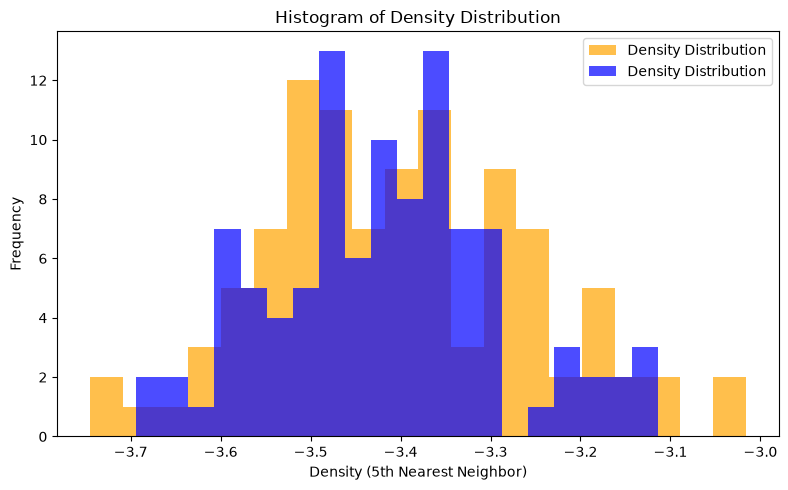

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(dens[0][dens[1] == 'barred'], bins=20, label='Density Distribution', color='orange', alpha=0.7, cumulative=False)
plt.hist(dens[0][dens[1] == 'unbarred'], bins=20, label='Density Distribution', color='blue', alpha=0.7, cumulative=False)
plt.xlabel('Density (5th Nearest Neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of Density Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
plt.show()

In [ ]:
# index_arr[index_arr != -999].size

In [ ]:
# dens = []
# for i, idx in enumerate(index_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance_arcmin.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [ ]:
# plt.hist(dens, bins = 50, label = 'Density Distribution', color = 'blue', alpha = 0.7)
# plt.xlabel('Density (5th Nearest Neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of Density Distribution')
# plt.legend()
# plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
# plt.show()